## Additional Visualizations

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from utils.synthetic_multivariate.visualizations import plot_sample_size_error_filtered, plot_time_per_iteration, plot_method_comparison_flexible
from utils.synthetic_GMM.visualizations_GMM import plot_sample_size_error_filtered_GMM, plot_time_per_iteration_GMM, plot_GMM_flexible

results_multivariate = pd.read_csv("results\\synthetic_multivariate\\simulation_results.csv")
results_gmm = pd.read_csv("results\\synthetic_gmm\\simulation_results_gmm.csv")

### EM Time per Iteration

We plot the average time per iteration for interesting instances to understand if it's the iteration effort to increase or just the steps to convergence

#### Multivariate Gaussian

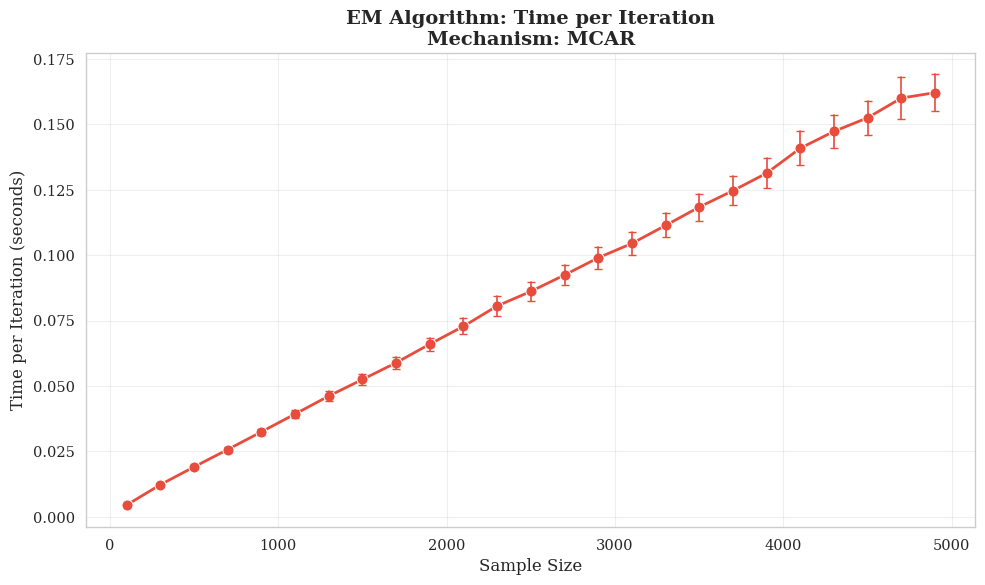

In [6]:
## SELECT ONLY INTERESTING CASES
plot_time_per_iteration(results_multivariate, 
                        x_axis="n_samples", 
                        mechanism='MCAR', 
                        mean_idx=None, 
                        cov_idx=None,
                        n_samples=None,
                        missingness_pct=None,
                        )
plt.show()

#### GMM

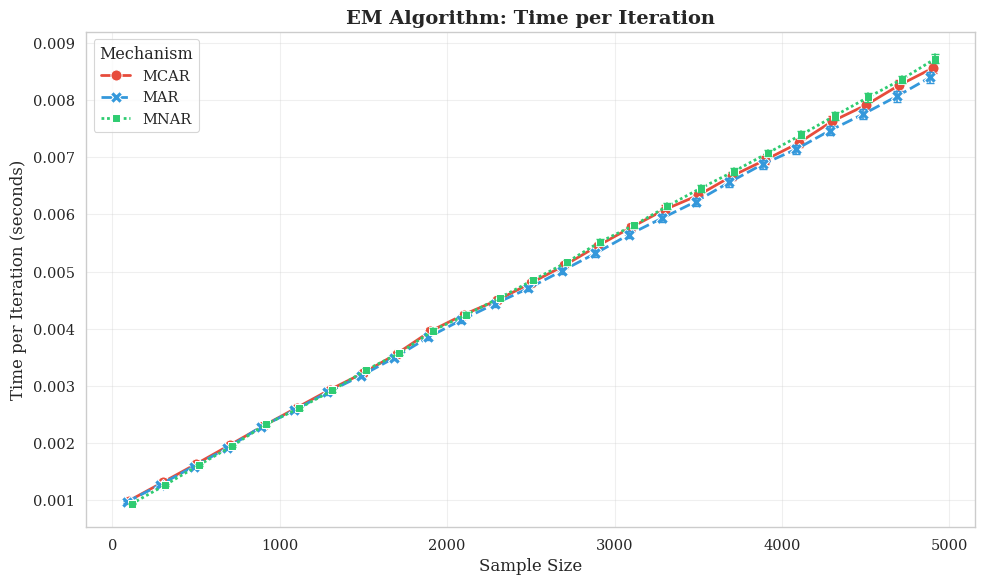

In [7]:
## SELECT ONLY INTERESTING CASES
plot_time_per_iteration_GMM(results_gmm, 
                            x_axis='n_samples',
                            mechanism=None, 
                            config_idx=None,
                            mean_idx=None, 
                            cov_idx=None,
                            weight_idx=None,
                            n_components=None,
                            n_samples=None,
                            missingness_pct=None,
                        )
plt.show()

### Error vs. Sample Size

We plot the error vs sample size just for intermediate missing percentages, to provide an overview of performances against an increasing observations

#### Multivariate Gaussian

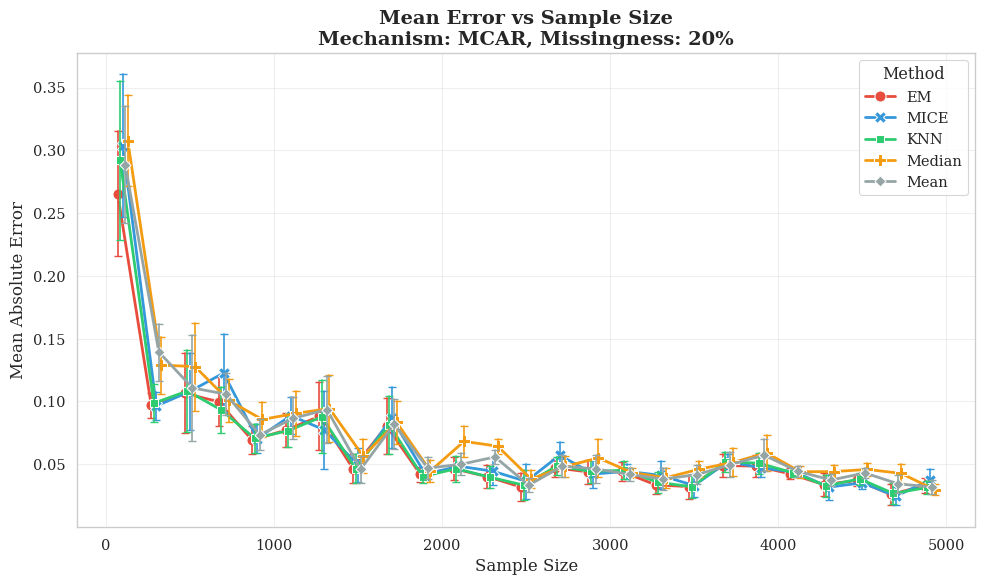

In [8]:
plot_sample_size_error_filtered(results_multivariate, mechanism='MCAR', missingness_pct=0.2)
plt.show()

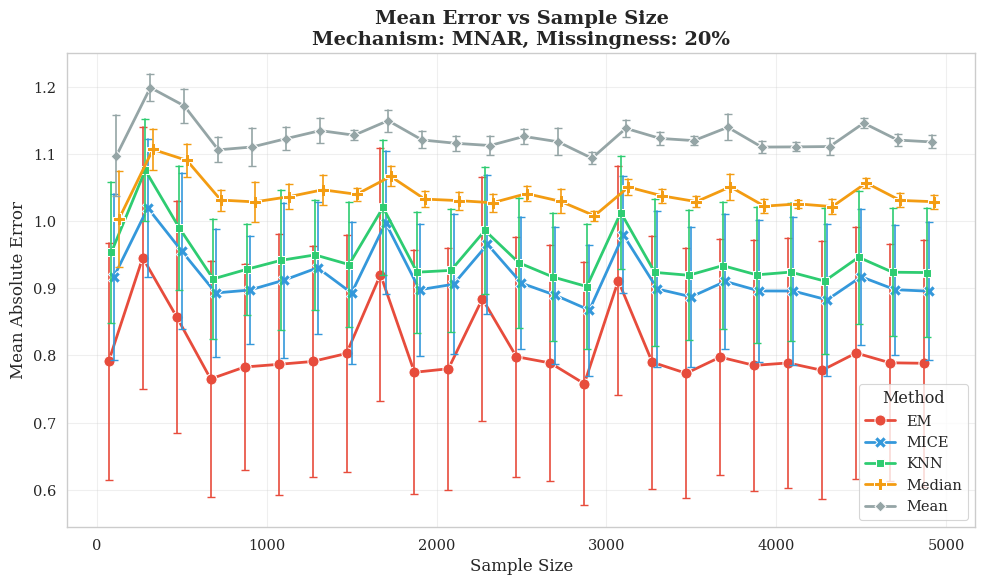

In [9]:
plot_sample_size_error_filtered(results_multivariate, mechanism='MNAR', missingness_pct=0.2)
plt.show()

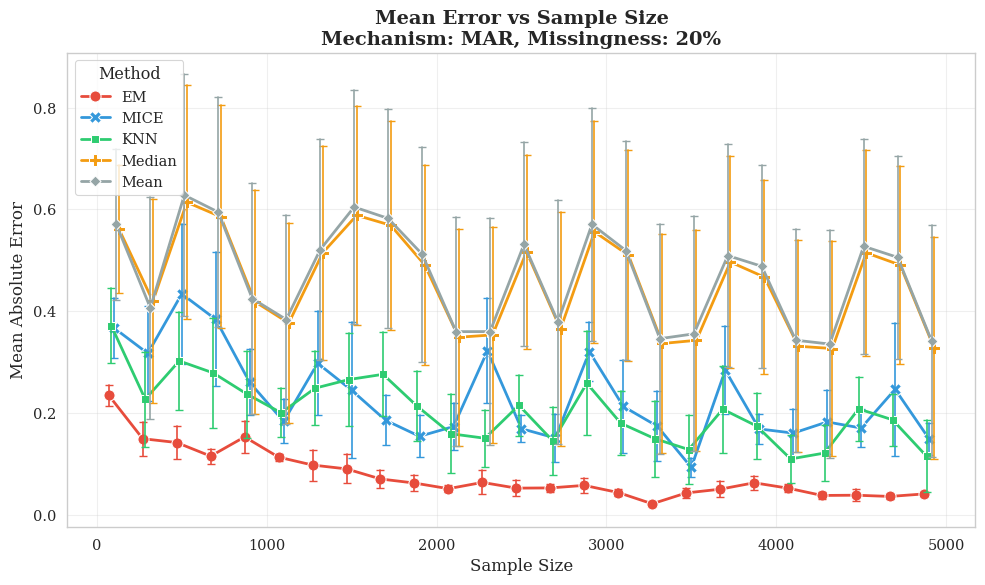

In [10]:
plot_sample_size_error_filtered(results_multivariate, mechanism='MAR', missingness_pct=0.2)
plt.show()

#### GMM

In [ ]:
plot_sample_size_error_filtered_GMM(results_gmm, mechanism='MCAR', missingness_pct=0.5)
plt.show()

In [ ]:
plot_sample_size_error_filtered_GMM(results_gmm, mechanism='MCAR', missingness_pct=0.5)
plt.show()

In [ ]:
plot_sample_size_error_filtered_GMM(results_gmm, mechanism='MCAR', missingness_pct=0.5)
plt.show()

### Plot Performances comparison on specific underlying initializations

#### Multivariate Gaussian

Plots for specific examples of initializations, our expectations:
- ...
- ...
- ...   

In [ ]:
plot_method_comparison_flexible(results_multivariate, 
                                   x_axis='n_samples',
                                   y_axis='time',
                                   mechanism=None,
                                   missingness_pct=None,
                                   n_samples=None,
                                   mean_idx=None,
                                   cov_idx=None,
                                   methods=None,
                                   log_scale=None,
                                   figsize=(10, 6))

#### GMM

Plots for specific examples of initializations, our expectations:
- ...
- ...
- ...   

In [ ]:
plot_GMM_flexible(results_gmm, 
                     x_axis='n_samples', # choose what to visualize on x axis
                     y_axis='time_per_iteration', # choose what to visualize on y axis
                     mechanism=None, 
                     config_idx=None, # choose a specific configuration index to filter
                     mean_idx=None, # choose a specific mean index to filter
                     cov_idx=None,# choose a specific covariance index to filter
                     weight_idx=None,
                     n_components=None,
                     n_samples=None,
                     missingness_pct=None,
                     hue=None,  # Can be 'mechanism', 'n_components', 'missingness_pct', etc.
                     figsize=(10, 6))

### GMM visualizations (extra)

Just for better visualizing EM 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse
from ipywidgets import interact, IntSlider, Button, HBox, VBox, Output
from IPython.display import display, clear_output

# Your existing EM functions (simplified for visualization)
def initialize_parameters(X, y, n_components, random_state=42):
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    
    pi = np.ones(n_components) / n_components
    mu = np.zeros((n_components, n_features))
    Sigma = []
    
    global_mean = np.mean(X, axis=0)
    global_cov = np.cov(X, rowvar=False)
    
    for c in range(n_components):
        X_c = X[y == c]
        
        if len(X_c) > 1:
            mu[c] = np.mean(X_c, axis=0)
            cov_c = np.cov(X_c, rowvar=False) + np.eye(n_features) * 1e-6
            Sigma.append(cov_c)
            pi[c] = len(X_c) / len(y[y != -1])
        else:
            mu[c] = global_mean + np.random.randn(n_features) * 0.1
            Sigma.append(global_cov + np.eye(n_features) * 1e-6)
            
    pi = pi / np.sum(pi)
    return pi, mu, Sigma

def e_step_semi_supervised(X, y, pi, mu, Sigma):
    N, K = len(X), len(pi)
    responsibilities = np.zeros((N, K))
    
    for k in range(K):
        try:
            responsibilities[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k], allow_singular=True)
        except:
            responsibilities[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k] + np.eye(X.shape[1])*1e-5)

    row_sums = responsibilities.sum(axis=1)[:, np.newaxis]
    row_sums[row_sums == 0] = 1e-10
    responsibilities = responsibilities / row_sums
    
    for i in range(N):
        if not np.isnan(y[i]):
            true_class = int(y[i])
            responsibilities[i, :] = 0.0
            responsibilities[i, true_class] = 1.0
            
    return responsibilities

def m_step_semi_supervised(X, responsibilities):
    N, D = X.shape
    K = responsibilities.shape[1]
    
    N_c = responsibilities.sum(axis=0)
    pi_new = N_c / N
    
    mu_new = np.zeros((K, D))
    Sigma_new = []
    
    for k in range(K):
        total_weight = N_c[k] if N_c[k] > 1e-10 else 1.0
        mu_k = np.sum(responsibilities[:, k].reshape(-1, 1) * X, axis=0) / total_weight
        mu_new[k] = mu_k
        
        diff = X - mu_k
        sigma_k = np.dot((responsibilities[:, k].reshape(-1, 1) * diff).T, diff) / total_weight
        sigma_k += np.eye(D) * 1e-5
        Sigma_new.append(sigma_k)
        
    return pi_new, mu_new, Sigma_new

def run_em_with_history(X, y, n_components, max_iter=30):
    """Run EM and store state at each iteration"""
    pi, mu, Sigma = initialize_parameters(X, y, n_components)
    
    history = {
        'mu': [mu.copy()],
        'Sigma': [[s.copy() for s in Sigma]],
        'pi': [pi.copy()],
        'responsibilities': [None]  # No responsibilities at init
    }
    
    for iteration in range(max_iter):
        responsibilities = e_step_semi_supervised(X, y, pi, mu, Sigma)
        pi, mu, Sigma = m_step_semi_supervised(X, responsibilities)
        
        history['mu'].append(mu.copy())
        history['Sigma'].append([s.copy() for s in Sigma])
        history['pi'].append(pi.copy())
        history['responsibilities'].append(responsibilities.copy())
    
    return history

def plot_gmm_iteration(X, y, history, iteration, figsize=(12, 8)):
    """Plot GMM state at a specific iteration"""
    fig, ax = plt.subplots(figsize=figsize)
    
    n_components = len(history['mu'][0])
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    mu = history['mu'][iteration]
    Sigma = history['Sigma'][iteration]
    responsibilities = history['responsibilities'][iteration]
    pi = history['pi'][iteration]
    
    # Determine point assignments
    if responsibilities is not None:
        assignments = np.argmax(responsibilities, axis=1)
    else:
        assignments = np.zeros(len(X), dtype=int)
    
    # Plot unlabeled points
    unlabeled_mask = np.isnan(y)
    for c in range(n_components):
        mask = (assignments == c) & unlabeled_mask
        if np.sum(mask) > 0:
            ax.scatter(X[mask, 0], X[mask, 1], 
                      c=colors[c], alpha=0.4, s=30, 
                      label=f'Cluster {c} (unlabeled)')
    
    # Plot labeled points
    labeled_mask = ~np.isnan(y)
    for c in range(n_components):
        mask = (y == c) & labeled_mask
        if np.sum(mask) > 0:
            ax.scatter(X[mask, 0], X[mask, 1], 
                      c=colors[c], alpha=1.0, s=50, 
                      edgecolors='white', linewidths=2,
                      label=f'Cluster {c} (labeled)')
    
    # Plot cluster centers and covariance ellipses
    for c in range(n_components):
        # Center
        ax.scatter(mu[c, 0], mu[c, 1], 
                  c=colors[c], s=200, marker='*', 
                  edgecolors='black', linewidths=2,
                  label=f'μ{c} (π={pi[c]:.3f})', zorder=10)
        
        # Covariance ellipse (2 standard deviations)
        if Sigma is not None:
            eigenvalues, eigenvectors = np.linalg.eigh(Sigma[c])
            angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
            width, height = 2 * 2 * np.sqrt(eigenvalues)  # 2 std devs
            
            ellipse = Ellipse(mu[c], width, height, angle=angle,
                            facecolor=colors[c], alpha=0.2, 
                            edgecolor=colors[c], linewidth=2)
            ax.add_patch(ellipse)
    
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(f'Semi-Supervised GMM - Iteration {iteration}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Create custom legend (avoid duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.show()

def interactive_gmm_visualization(X, y, n_components=3, max_iter=30):
    """
    Create interactive visualization with slider for Jupyter notebooks
    
    Usage:
        interactive_gmm_visualization(X, y_semi, n_components=3, max_iter=30)
    """
    
    # Run EM and get history
    print("Running EM algorithm...")
    history = run_em_with_history(X, y, n_components, max_iter)
    print(f"Completed {max_iter} iterations")
    
    # Display info
    labeled_count = np.sum(~np.isnan(y))
    unlabeled_count = np.sum(np.isnan(y))
    print(f"\nDataset Info:")
    print(f"  Total points: {len(X)}")
    print(f"  Labeled: {labeled_count} ({100*labeled_count/len(X):.1f}%)")
    print(f"  Unlabeled: {unlabeled_count} ({100*unlabeled_count/len(X):.1f}%)")
    print(f"  Number of components: {n_components}")
    print("\nUse the slider below to navigate through EM iterations:")
    
    # Create interactive widget
    def update_plot(iteration):
        plot_gmm_iteration(X, y, history, iteration, figsize=(12, 8))
    
    # Create slider widget
    interact(update_plot, 
             iteration=IntSlider(min=0, max=max_iter, step=1, value=0, 
                                description='Iteration:', 
                                style={'description_width': 'initial'},
                                layout={'width': '600px'}))

# ============================================================================
# Example Usage
# ============================================================================

def generate_complex_data(n_samples_per_cluster=80, random_state=42):
    """
    Generate more interesting overlapping clusters with different shapes
    """
    np.random.seed(random_state)
    
    # Cluster 0: Elongated diagonal cluster (top-left to bottom-right)
    cov0 = np.array([[2.0, 1.5],    # Strong positive correlation
                     [1.5, 0.8]])
    mean0 = np.array([1, 6])
    X0 = np.random.multivariate_normal(mean0, cov0, n_samples_per_cluster)
    
    # Cluster 1: Round, compact cluster (bottom-right)
    cov1 = np.array([[0.5, 0.0],    # Spherical, small variance
                     [0.0, 0.5]])
    mean1 = np.array([6, 1])
    X1 = np.random.multivariate_normal(mean1, cov1, n_samples_per_cluster)
    
    # Cluster 2: Elongated horizontal cluster (middle-left)
    cov2 = np.array([[3.0, -0.5],   # Negative correlation, stretched horizontally
                     [-0.5, 0.6]])
    mean2 = np.array([3, 4])
    X2 = np.random.multivariate_normal(mean2, cov2, n_samples_per_cluster)
    
    X = np.vstack([X0, X1, X2])
    y_true = np.array([0]*n_samples_per_cluster + 
                      [1]*n_samples_per_cluster + 
                      [2]*n_samples_per_cluster)
    
    return X, y_true

# Generate interesting overlapping data
X, y_true = generate_complex_data(n_samples_per_cluster=80, random_state=42)

# Create semi-supervised scenario with very few labels (95% unlabeled)
y_semi = y_true.copy().astype(float)
mask = np.random.rand(len(y_semi)) < 0.95  # Only 5% labeled!
y_semi[mask] = np.nan

# Ensure we have at least 2 labels per class for better initialization
np.random.seed(42)
for c in range(3):
    class_indices = np.where(y_true == c)[0]
    # Force at least 3 labels per class
    forced_labels = np.random.choice(class_indices, size=min(3, len(class_indices)), replace=False)
    y_semi[forced_labels] = c

# Run interactive visualization
print("=" * 60)
print("INTERACTIVE GMM VISUALIZATION")
print("=" * 60)
print("\nDataset characteristics:")
print("  - Cluster 0: Elongated diagonal (positive correlation)")
print("  - Cluster 1: Compact spherical (bottom-right)")
print("  - Cluster 2: Elongated horizontal (negative correlation)")
print("  - Clusters are intentionally overlapping!")
print()
interactive_gmm_visualization(X, y_semi, n_components=3, max_iter=50)

INTERACTIVE GMM VISUALIZATION

Dataset characteristics:
  - Cluster 0: Elongated diagonal (positive correlation)
  - Cluster 1: Compact spherical (bottom-right)
  - Cluster 2: Elongated horizontal (negative correlation)
  - Clusters are intentionally overlapping!

Running EM algorithm...
Completed 50 iterations

Dataset Info:
  Total points: 240
  Labeled: 17 (7.1%)
  Unlabeled: 223 (92.9%)
  Number of components: 3

Use the slider below to navigate through EM iterations:


C:\Users\leona\AppData\Local\Temp\ipykernel_11924\2318762613.py:218: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X0 = np.random.multivariate_normal(mean0, cov0, n_samples_per_cluster)


interactive(children=(IntSlider(value=0, description='Iteration:', layout=Layout(width='600px'), max=50, style…